In [1]:
import pandas as pd
import numpy as np

# 1. 加载数据
file_path = r'C:\jupyterfile\data\辽宁省2025年空气质量数据.csv'

# 注意：如果报错 'utf-8' 编码问题，请把下面的 encoding='utf-8' 改为 encoding='gbk'
try:
    df = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8解码失败，尝试使用GBK编码...")
    df = pd.read_csv(file_path, encoding='gbk')

print("="*50)
print("【1. 数据前5行预览（看一眼长什么样）】")
print(df.head())
print("\n" + "="*50)

print("【2. 所有列名（这最重要！我需要知道列名才能给你画图代码）】")
print(df.columns.tolist())
print("\n" + "="*50)

print("【3. 数据形状（行数和列数）】")
print(f"数据共有 {df.shape[0]} 行，{df.shape[1]} 列")
print("\n" + "="*50)

print("【4. 有无缺失值（检查数据质量）】")
print(df.isnull().sum())
print("\n" + "="*50)

print("【5. 数据类型（看时间列是不是日期格式）】")
print(df.dtypes)

【1. 数据前5行预览（看一眼长什么样）】
   城市                时间  PM10(μg/m³)  PM2.5(μg/m³)  CO(μg/m³)  NO₂(μg/m³)  \
0  沈阳  2025-01-01T00:00         30.9          25.0      283.0        33.4   
1  沈阳  2025-01-01T01:00         24.7          19.0      272.0        17.5   
2  沈阳  2025-01-01T02:00         21.9          18.0      285.0         6.4   
3  沈阳  2025-01-01T03:00         22.6          20.6      235.0         3.3   
4  沈阳  2025-01-01T04:00         25.1          24.1      207.0         5.0   

   SO₂(μg/m³)  O₃(μg/m³)  AQI  
0        41.9       32.0   65  
1        20.8       46.0   65  
2         6.0       55.0   65  
3         1.8       56.0   65  
4         3.7       53.0   65  

【2. 所有列名（这最重要！我需要知道列名才能给你画图代码）】
['城市', '时间', 'PM10(μg/m³)', 'PM2.5(μg/m³)', 'CO(μg/m³)', 'NO₂(μg/m³)', 'SO₂(μg/m³)', 'O₃(μg/m³)', 'AQI']

【3. 数据形状（行数和列数）】
数据共有 122640 行，9 列

【4. 有无缺失值（检查数据质量）】
城市              0
时间              0
PM10(μg/m³)     0
PM2.5(μg/m³)    0
CO(μg/m³)       0
NO₂(μg/m³)      0
SO₂(μg/m³)      0
O₃(

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
file_path = r'C:\jupyterfile\data\辽宁省2025年空气质量数据.csv'
df = pd.read_csv(file_path, encoding='utf-8')

# ===== 时间列处理 =====
# 原始时间格式是 '2025-01-01T00:00'，需要转为标准datetime
df['时间'] = pd.to_datetime(df['时间'], format='%Y-%m-%dT%H:%M')

# 提取时间特征
df['年'] = df['时间'].dt.year
df['月'] = df['时间'].dt.month
df['日'] = df['时间'].dt.day
df['小时'] = df['时间'].dt.hour
df['周数'] = df['时间'].dt.isocalendar().week

# 定义季节
def get_season(month):
    if month in [12, 1, 2]:
        return '冬季'
    elif month in [3, 4, 5]:
        return '春季'
    elif month in [6, 7, 8]:
        return '夏季'
    else:
        return '秋季'

df['季节'] = df['月'].apply(get_season)

# 重命名列名
df.rename(columns={
    '城市': 'city',
    '时间': 'time',
    'PM10(μg/m³)': 'PM10',
    'PM2.5(μg/m³)': 'PM2.5',
    'CO(μg/m³)': 'CO',
    'NO₂(μg/m³)': 'NO2',
    'SO₂(μg/m³)': 'SO2',
    'O₃(μg/m³)': 'O3',
    'AQI': 'AQI'
}, inplace=True)

# 保存清洗后的数据
df.to_csv(r'C:\jupyterfile\data\liaoning_aqi_cleaned.csv', index=False)
print(f"✅ 清洗完成！数据共 {len(df)} 条记录，{df['city'].nunique()} 个城市")
print(f"时间范围：{df['time'].min()} 至 {df['time'].max()}")

✅ 清洗完成！数据共 122640 条记录，14 个城市
时间范围：2025-01-01 00:00:00 至 2025-12-31 23:00:00


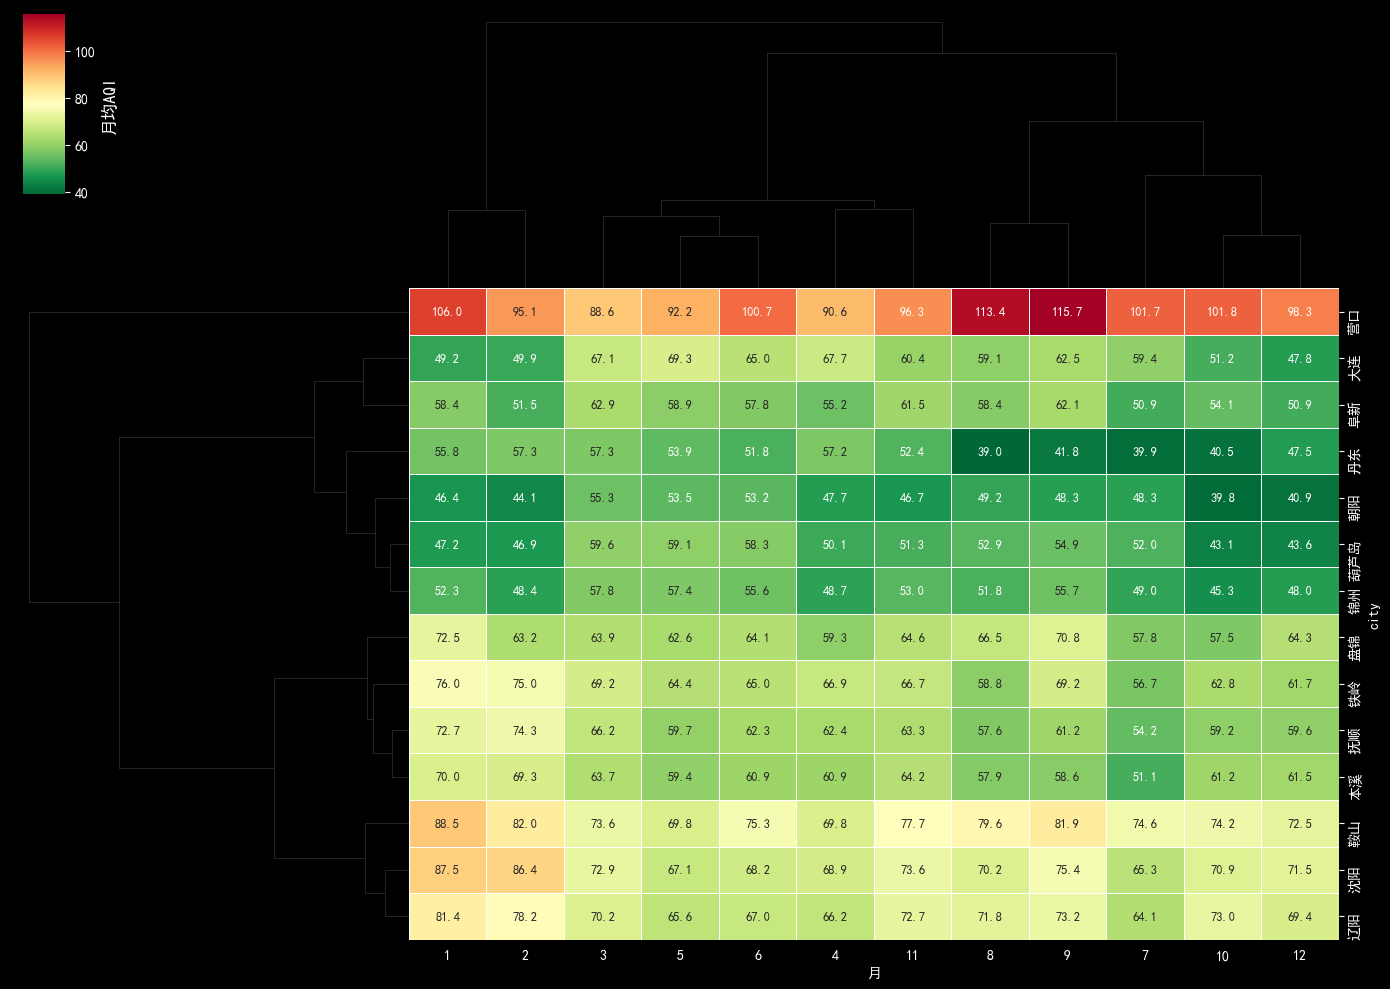

✅ 热力图已生成！树状图线条已改为亮绿色（#00FF00）


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 准备数据
monthly_avg = df.groupby(['city', '月'])['AQI'].mean().reset_index()
pivot_table = monthly_avg.pivot(index='city', columns='月', values='AQI')

# ===== 第一步：正常绘制热力图 =====
g = sns.clustermap(
    pivot_table,
    method='ward',
    cmap='RdYlGn_r',
    figsize=(14, 10),
    dendrogram_ratio=0.3,
    cbar_pos=(0.02, 0.8, 0.03, 0.18),
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='.1f',
    annot_kws={'size': 9},
    row_cluster=True,
    col_cluster=True
)

for line in g.ax_row_dendrogram.get_lines():
    line.set_color('#00FF00')      # 亮绿色
    line.set_linewidth(2.5)        # 加粗一点更显眼

for line in g.ax_col_dendrogram.get_lines():
    line.set_color('white')      # 同样亮绿色
    line.set_linewidth(2.5)

g.ax_cbar.set_ylabel('月均AQI', fontsize=12)

# 保存
os.makedirs(r'C:\jupyterfile\data\outputs', exist_ok=True)
plt.savefig(r'C:\jupyterfile\data\outputs\图1_层次聚类热力矩阵_亮绿线条.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 热力图已生成！树状图线条已改为亮绿色（#00FF00）")

In [6]:
# 正确的导入方式
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist   # ✅ pdist 在这里
import pandas as pd

# 重新计算行聚类
row_linkage = linkage(pdist(pivot_table.values), method='ward')

# 分成3组
clusters = fcluster(row_linkage, t=3, criterion='maxclust')
city_cluster = pd.DataFrame({
    '城市': pivot_table.index,
    '污染模式分组': clusters
}).sort_values('污染模式分组')

print("=== 城市聚类分组结果 ===")
print(city_cluster)

=== 城市聚类分组结果 ===
     城市  污染模式分组
0    丹东       1
1    大连       1
3    朝阳       1
8   葫芦岛       1
11   锦州       1
12   阜新       1
2    抚顺       2
4    本溪       2
5    沈阳       2
6    盘锦       2
9    辽阳       2
10   铁岭       2
13   鞍山       2
7    营口       3


In [7]:
# 辽宁省14个城市的经纬度（从高德地图获取）
city_coords = {
    '沈阳': [123.4315, 41.8057],
    '大连': [121.6147, 38.9140],
    '鞍山': [122.9956, 41.1106],
    '抚顺': [123.9572, 41.8811],
    '本溪': [123.7700, 41.3005],
    '丹东': [124.3830, 40.1290],
    '锦州': [121.1350, 41.1150],
    '营口': [122.2350, 40.6680],
    '阜新': [121.6700, 42.0200],
    '辽阳': [123.2370, 41.2670],
    '盘锦': [122.0700, 41.1300],
    '铁岭': [123.8400, 42.2900],
    '朝阳': [120.4500, 41.5800],
    '葫芦岛': [120.8400, 40.7200]
}

# 转为DataFrame
coords_df = pd.DataFrame.from_dict(city_coords, orient='index', columns=['经度', '纬度'])
coords_df.index.name = 'city'
coords_df = coords_df.reset_index()

print(coords_df)

   city        经度       纬度
0    沈阳  123.4315  41.8057
1    大连  121.6147  38.9140
2    鞍山  122.9956  41.1106
3    抚顺  123.9572  41.8811
4    本溪  123.7700  41.3005
5    丹东  124.3830  40.1290
6    锦州  121.1350  41.1150
7    营口  122.2350  40.6680
8    阜新  121.6700  42.0200
9    辽阳  123.2370  41.2670
10   盘锦  122.0700  41.1300
11   铁岭  123.8400  42.2900
12   朝阳  120.4500  41.5800
13  葫芦岛  120.8400  40.7200


In [8]:
!pip install plotly --upgrade -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import plotly.express as px
import plotly.io as pio
import pandas as pd

# 关键：设置渲染器为 iframe
pio.renderers.default = 'iframe'

# 准备数据
city_avg = df.groupby('city')['AQI'].mean().reset_index()
city_avg.columns = ['city', 'avg_aqi']
map_data = city_avg.merge(coords_df, on='city')

# 绘图
fig = px.scatter_map(
    map_data,
    lat='纬度',
    lon='经度',
    size='avg_aqi',
    color='avg_aqi',
    color_continuous_scale='RdYlGn_r',
    size_max=50,
    hover_name='city',
    hover_data={'avg_aqi': ':.1f'},
    title='辽宁省2025年各城市年均AQI空间分布（交互式）',
    map_style='carto-positron',   # 更轻量的底图
    zoom=5.5,
    center={'lat': 41.5, 'lon': 123.0}
)

fig.update_layout(width=900, height=700)
fig.show()

# 保存（已存在，覆盖）
fig.write_html(r'C:\jupyterfile\data\outputs\图2_气泡地图_interactive.html')
print("✅ 已重新生成！请到 outputs 文件夹双击 HTML 文件查看。")

✅ 已重新生成！请到 outputs 文件夹双击 HTML 文件查看。


In [16]:
import plotly.express as px

# 计算各城市月度均值
monthly_trend = df.groupby(['city', '月'])['AQI'].mean().reset_index()

# 绘制分面折线图
fig = px.line(
    monthly_trend,
    x='月',
    y='AQI',
    color='city',
    facet_col='city',
    facet_col_wrap=4,
    title='辽宁省14个城市2025年AQI月度变化趋势',
    labels={'月': '月份', 'AQI': '月均AQI'},
    height=900,
    width=1100
)

fig.update_traces(line=dict(width=2))
fig.update_xaxes(tickvals=[1,3,5,7,9,11], ticktext=['1月','3月','5月','7月','9月','11月'])

fig.show()
fig.write_html(r'C:\jupyterfile\data\outputs\图3_分面趋势图.html')
print("✅ 分面趋势图已保存！")

✅ 分面趋势图已保存！


In [21]:
import plotly.express as px
import pandas as pd
import numpy as np

# ===== 确保 AQI 在污染物列表中 =====
pollutants = ['PM10', 'PM2.5', 'CO', 'NO2', 'SO2', 'O3', 'AQI']  # ✅ AQI 已包含
corr_matrix = df[pollutants].corr()

# 转换为长格式
corr_melted = corr_matrix.reset_index().melt(id_vars='index')
corr_melted.columns = ['污染物1', '污染物2', '相关系数']
corr_melted['abs_corr'] = corr_melted['相关系数'].abs()

# 只保留上三角（去除重复和自相关）
pairs = set()
filtered = []
for _, row in corr_melted.iterrows():
    key = tuple(sorted([row['污染物1'], row['污染物2']]))
    if key not in pairs and row['污染物1'] != row['污染物2']:
        pairs.add(key)
        filtered.append(row)
corr_plot = pd.DataFrame(filtered)

# 绘制气泡图
fig = px.scatter(
    corr_plot,
    x='污染物1',
    y='污染物2',
    size='abs_corr',
    color='相关系数',
    color_continuous_scale='RdYlGn_r',
    text='相关系数',
    title='辽宁省空气质量污染物相关性矩阵（含AQI）',
    labels={'污染物1': '', '污染物2': '', '相关系数': ''},
    width=900,
    height=700
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='middle center',
    marker=dict(sizemode='diameter')
)

fig.update_layout(
    xaxis=dict(tickangle=45),
    coloraxis_colorbar=dict(title='相关系数')
)

fig.show()
fig.write_html(r'C:\jupyterfile\data\outputs\图4_相关性气泡图_含AQI.html')
print("✅ 包含AQI的气泡图已保存！")

✅ 包含AQI的气泡图已保存！


In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ===== 1. 计算各城市各污染物的年均值 =====
city_pollutants = df.groupby('city')[['PM10', 'PM2.5', 'CO', 'NO2', 'SO2', 'O3']].mean().reset_index()

# ===== 2. 标准化（MinMax归一化，使不同量纲的污染物可在同一张雷达图上对比） =====
scaler = MinMaxScaler()
pollutants = ['PM10', 'PM2.5', 'CO', 'NO2', 'SO2', 'O3']
city_pollutants_scaled = city_pollutants.copy()
city_pollutants_scaled[pollutants] = scaler.fit_transform(city_pollutants[pollutants])

# ===== 3. 选择代表性城市（高、中、低污染各选2个） =====
selected_cities = ['营口', '鞍山', '沈阳', '辽阳', '朝阳', '丹东']
plot_data = city_pollutants_scaled[city_pollutants_scaled['city'].isin(selected_cities)]

print("✅ 数据准备完成！")
print(plot_data)

✅ 数据准备完成！
   city      PM10     PM2.5        CO       NO2       SO2        O3
0    丹东  0.000000  0.037257  0.060562  0.000000  0.018617  0.786699
3    朝阳  0.004311  0.000000  0.028149  0.047856  0.000000  0.826204
5    沈阳  0.394220  0.424243  1.000000  0.425520  0.150264  0.518354
7    营口  1.000000  1.000000  0.583361  1.000000  1.000000  0.000000
9    辽阳  0.346454  0.372012  0.469263  0.572834  0.274522  0.409411
13   鞍山  0.471909  0.496026  0.495677  0.613126  0.354091  0.326475


In [23]:
# ===== 创建6个子图的雷达图矩阵（2行×3列） =====
fig = make_subplots(
    rows=2, cols=3,
    specs=[[{'type': 'polar'}]*3]*2,
    subplot_titles=selected_cities
)

# 颜色方案（按污染程度渐变）
colors = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850', '#1a9850']

# 污染物名称（用于雷达图的维度）
pollutants_labels = ['PM10', 'PM2.5', 'CO', 'NO₂', 'SO₂', 'O₃']

# 依次添加每个城市的雷达图
row, col = 1, 1
for idx, city in enumerate(selected_cities):
    city_data = plot_data[plot_data['city'] == city]
    values = city_data[pollutants].values.flatten().tolist()
    # 闭合雷达图（首尾相连）
    values_closed = values + values[:1]

    fig.add_trace(
        go.Scatterpolar(
            r=values_closed,
            theta=pollutants_labels + [pollutants_labels[0]],
            fill='toself',
            name=city,
            line=dict(color=colors[idx], width=2),
            marker=dict(size=4)
        ),
        row=row, col=col
    )

    # 更新列和行
    col += 1
    if col > 3:
        col = 1
        row += 1

# ===== 更新布局 =====
fig.update_layout(
    title=dict(
        text='辽宁省代表性城市六项污染物标准化对比（雷达图）<br><sup>数值经过MinMax归一化，数值越大表示该污染物浓度越高</sup>',
        font=dict(size=16)
    ),
    height=800,
    width=1100,
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

# 更新每个子图的雷达图样式
fig.update_polars(
    radialaxis=dict(
        visible=True,
        range=[0, 1],
        tickvals=[0, 0.5, 1],
        ticktext=['低', '中', '高']
    ),
    angularaxis=dict(
        tickfont=dict(size=10)
    )
)

fig.show()
fig.write_html(r'C:\jupyterfile\data\outputs\图5_雷达图矩阵.html')
print("✅ 雷达图矩阵已保存！")

✅ 雷达图矩阵已保存！


C:\Users\31745\AppData\Local\Temp\ipykernel_26564\2127883170.py:57: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
C:\Users\31745\AppData\Local\Temp\ipykernel_26564\2127883170.py:57: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from current font.
  plt.tight_layout()
C:\Users\31745\AppData\Local\Temp\ipykernel_26564\2127883170.py:58: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig(r'C:\jupyterfile\data\outputs\图6_小提琴分布图.png', dpi=300, bbox_inches='tight')
C:\Users\31745\AppData\Local\Temp\ipykernel_26564\2127883170.py:58: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from current font.
  plt.savefig(r'C:\jupyterfile\data\outputs\图6_小提琴分布图.png', dpi=300, bbox_inches='tight')
C:\Users\31745\PyCharmMiscProject\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31745\

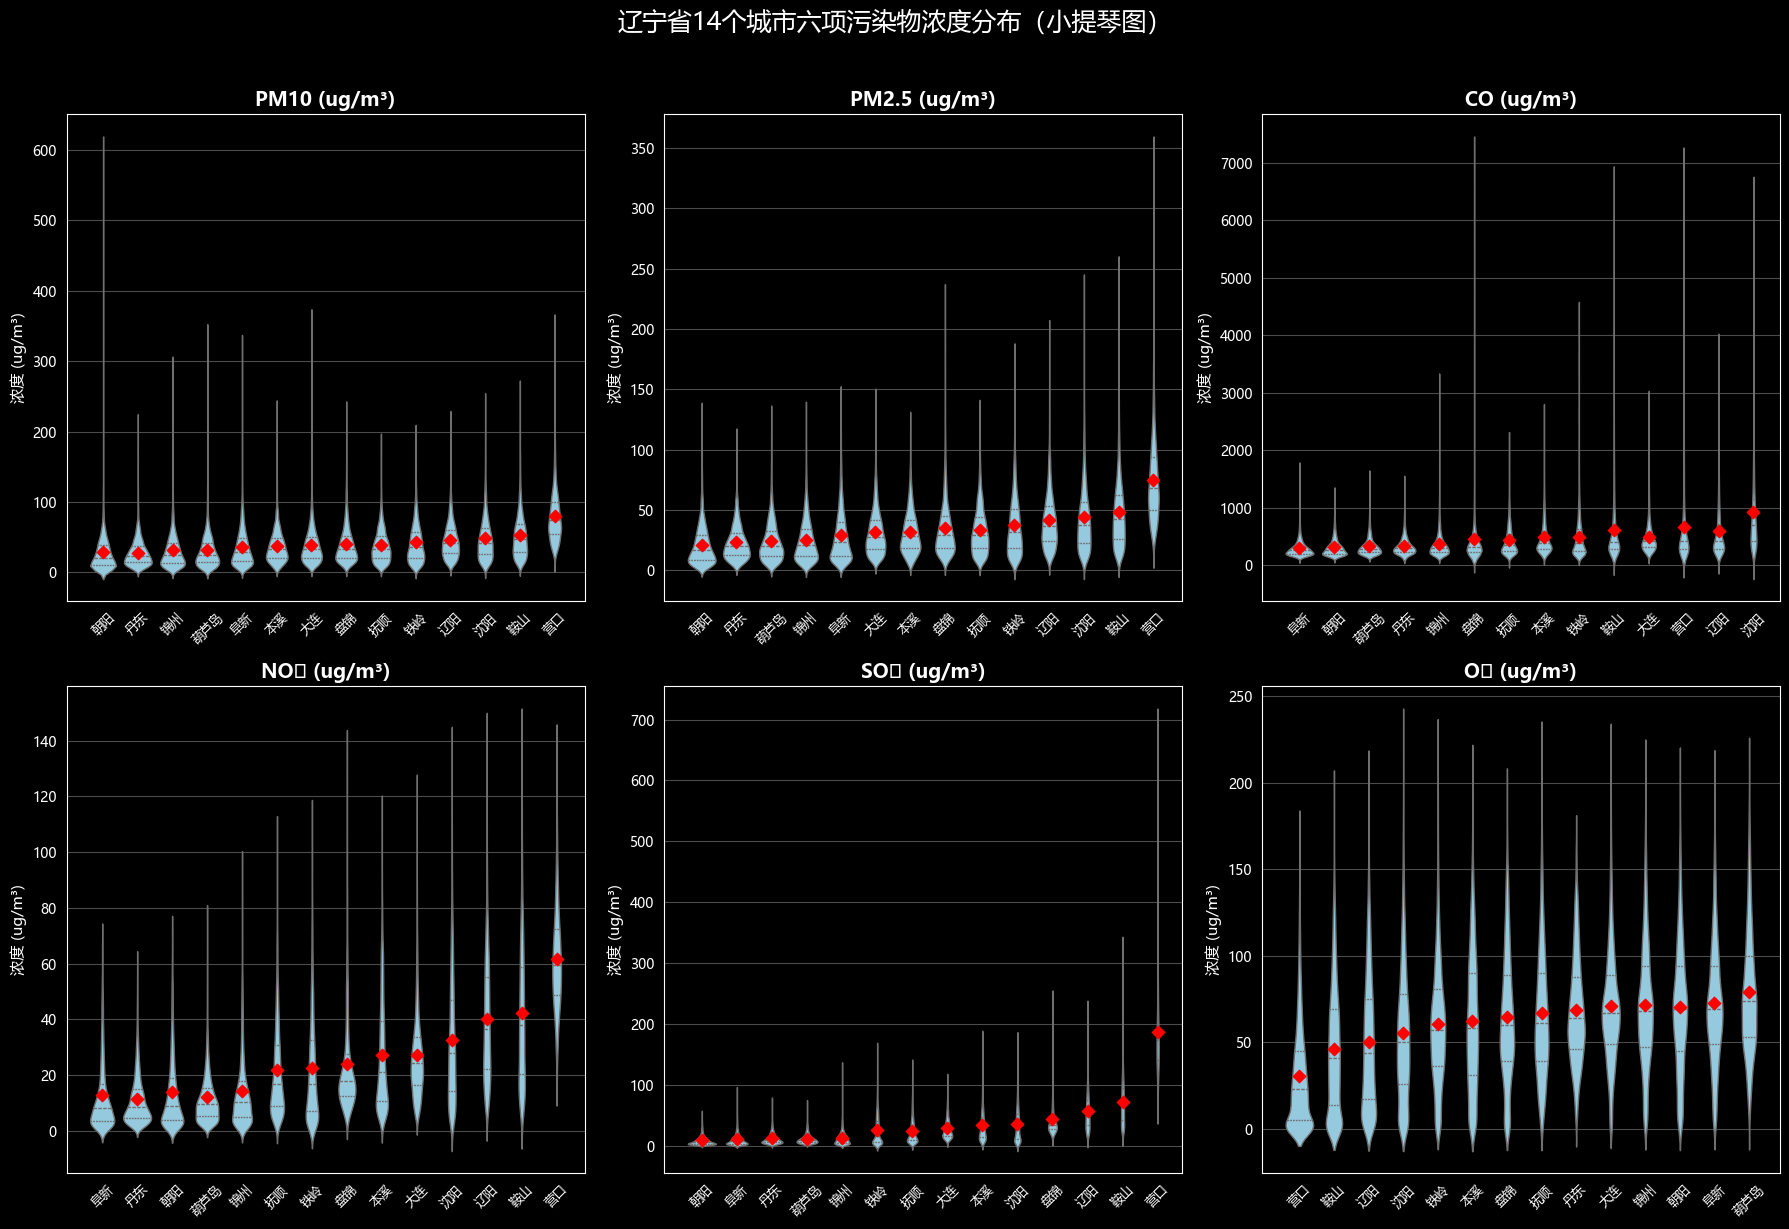

✅ 小提琴图已成功保存（无警告版本）！


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# ===== 强制设置支持中文和上标/下标的字体 =====
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

os.makedirs(r'C:\jupyterfile\data\outputs', exist_ok=True)

# 准备数据（长格式）
violin_data = df[['city', 'PM10', 'PM2.5', 'CO', 'NO2', 'SO2', 'O3']].copy()
violin_melted = violin_data.melt(
    id_vars=['city'],
    value_vars=['PM10', 'PM2.5', 'CO', 'NO2', 'SO2', 'O3'],
    var_name='污染物',
    value_name='浓度'
)

# 创建子图
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
pollutants_list = ['PM10', 'PM2.5', 'CO', 'NO2', 'SO2', 'O3']
# 使用纯文本单位，避免特殊字符
pollutants_labels = ['PM10 (ug/m³)', 'PM2.5 (ug/m³)', 'CO (ug/m³)', 'NO₂ (ug/m³)', 'SO₂ (ug/m³)', 'O₃ (ug/m³)']

for idx, (pollutant, label) in enumerate(zip(pollutants_list, pollutants_labels)):
    subset = violin_melted[violin_melted['污染物'] == pollutant]
    order = subset.groupby('city')['浓度'].median().sort_values().index.tolist()

    # 修正：移除 palette，使用 color
    sns.violinplot(
        data=subset,
        x='city',
        y='浓度',
        order=order,
        color='skyblue',          # 统一颜色
        inner='quartile',
        linewidth=1,
        ax=axes[idx]
    )

    # 添加均值点
    means = subset.groupby('city')['浓度'].mean()
    for i, city in enumerate(order):
        axes[idx].scatter(i, means[city], color='red', marker='D', s=40, zorder=5)

    axes[idx].set_title(label, fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('浓度 (ug/m³)', fontsize=11)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('辽宁省14个城市六项污染物浓度分布（小提琴图）', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(r'C:\jupyterfile\data\outputs\图6_小提琴分布图.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 小提琴图已成功保存（无警告版本）！")

In [26]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# ===== 1. 准备周数据 =====
# 计算每个城市每周的AQI均值
df['周数'] = df['time'].dt.isocalendar().week

# 选取8个主要城市（论文中使用的）
main_cities = ['沈阳', '大连', '鞍山', '抚顺', '本溪', '丹东', '锦州', '营口']
weekly_data = df[df['city'].isin(main_cities)].groupby(['city', '周数'])['AQI'].mean().reset_index()

# 转换为宽格式（行为周数，列为城市）
weekly_pivot = weekly_data.pivot(index='周数', columns='city', values='AQI').fillna(0)

# 按周数排序（1-52周）
weekly_pivot = weekly_pivot.sort_index()
weeks = weekly_pivot.index.tolist()

# ===== 2. 计算各城市的贡献（用于堆积流图） =====
# 为了堆积流图，我们需要各城市的AQI值，并计算累积和
city_names = main_cities
values = [weekly_pivot[city].values for city in city_names]

# 创建堆积流图（使用Plotly）
fig = go.Figure()

# 颜色方案（不同城市不同颜色）
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

# 添加每个城市的流带（使用堆积面积图）
for i, city in enumerate(city_names):
    fig.add_trace(go.Scatter(
        x=weeks,
        y=values[i],
        name=city,
        mode='none',
        fill='tonexty',  # 堆积效果
        fillcolor=colors[i % len(colors)],
        line=dict(width=0.5, color='white'),
        stackgroup='one',  # 关键：堆积
        groupnorm='percent'  # 归一化为百分比（可选）
    ))

# ===== 3. 添加参考线（全省均值） =====
# 计算全省每周平均AQI
weekly_all = df.groupby('周数')['AQI'].mean().reset_index()
weekly_all = weekly_all[weekly_all['周数'].isin(weeks)]

fig.add_trace(go.Scatter(
    x=weekly_all['周数'],
    y=weekly_all['AQI'],
    name='全省均值',
    mode='lines',
    line=dict(color='black', width=2, dash='dash'),
    yaxis='y2'  # 双轴显示
))

# ===== 4. 标记污染峰值周（第4-6周） =====
fig.add_vrect(
    x0=4, x1=6,
    fillcolor='yellow',
    opacity=0.2,
    line_width=0,
    annotation_text='污染峰值期',
    annotation_position='top left'
)

# ===== 5. 更新布局 =====
fig.update_layout(
    title='辽宁省主要城市AQI时间演变流线图（周度）',
    xaxis=dict(
        title='周数',
        tickmode='linear',
        dtick=4,
        tick0=1
    ),
    yaxis=dict(
        title='各城市AQI占比 (%)',
        ticksuffix='%'
    ),
    yaxis2=dict(
        title='全省均值 AQI',
        overlaying='y',
        side='right',
        showgrid=False
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    ),
    height=600,
    width=1000,
    hovermode='x unified'
)

fig.show()
fig.write_html(r'C:\jupyterfile\data\outputs\图7_时间演变流线图.html')
print("✅ 流线图已保存！")

✅ 流线图已保存！
